# Dimensionality Reduction

## Objective

In this notebook, we will practice:

- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- t-SNE
- UMAP
- Autoencoder

The original Heart Failure dataset will remain unchanged.

> A random `practice_target` will be used only to demonstrate LDA.
> It does not represent a real medical outcome.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

In [20]:
df = pd.read_csv(
    "../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [21]:
numerical_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

X = df[numerical_features].copy()

print("Original Shape:", X.shape)

Original Shape: (299, 6)


# Principal Component Analysis (PCA)

PCA combines information from multiple numerical features into fewer Principal Components.

PCA does not require a target variable.

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176


In [23]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.034853,-0.672180
1,1.757645,-3.197428
2,-1.943501,-1.260288
3,-0.583394,-1.277827
4,-3.904474,-1.573671


In [24]:
print("Before PCA:", X_scaled.shape)
print("After PCA:", pca_df.shape)

Before PCA: (299, 6)
After PCA: (299, 2)


In [25]:
explained_variance = (
    pca.explained_variance_ratio_
)

print(
    "PC1 Explained Variance:",
    round(explained_variance[0] * 100, 2),
    "%"
)

print(
    "PC2 Explained Variance:",
    round(explained_variance[1] * 100, 2),
    "%"
)

print(
    "Total Explained Variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

PC1 Explained Variance: 22.42 %
PC2 Explained Variance: 19.23 %
Total Explained Variance: 41.65 %


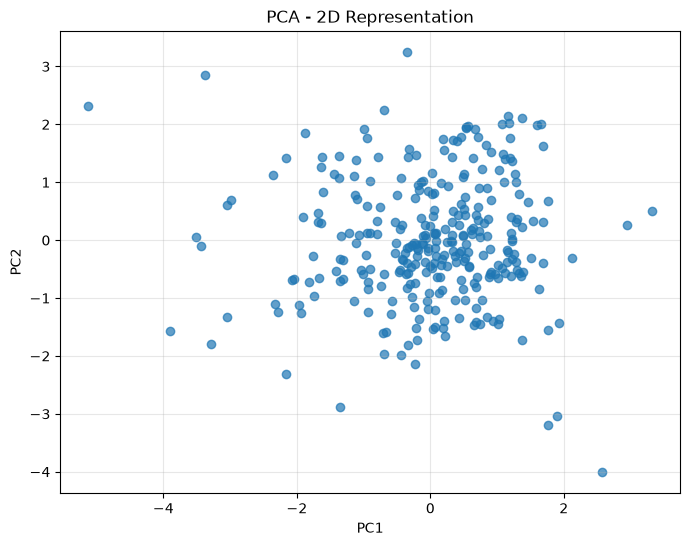

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - 2D Representation")
plt.grid(alpha=0.3)

plt.show()

# Linear Discriminant Analysis (LDA)

LDA is supervised.

It requires a target variable and tries to create dimensions that separate classes.

A random target is used here only for learning the workflow.

In [27]:
np.random.seed(42)

practice_target = np.random.randint(
    0,
    2,
    size=len(X_scaled)
)

print(
    pd.Series(
        practice_target
    ).value_counts()
)

0    151
1    148
Name: count, dtype: int64


In [28]:
lda = LinearDiscriminantAnalysis(
    n_components=1
)

X_lda = lda.fit_transform(
    X_scaled,
    practice_target
)

lda_df = pd.DataFrame({
    "LD1": X_lda.flatten(),
    "Practice Target": practice_target
})

lda_df.head()

,LD1,Practice Target
0,-0.942255,0
1,-3.235473,1
2,-0.930896,0
3,-0.338831,0
4,-2.380578,0


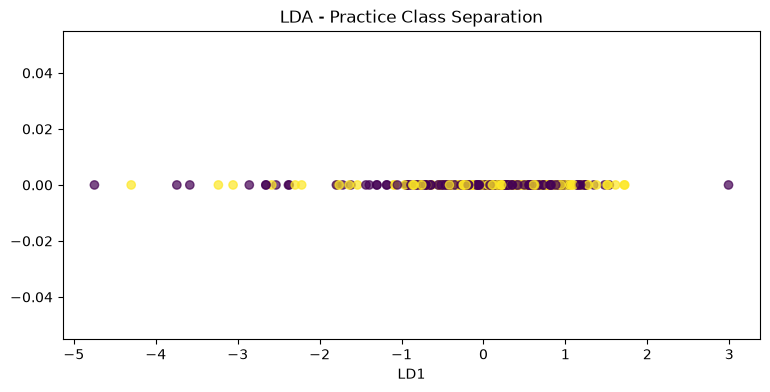

In [29]:
plt.figure(figsize=(9, 4))

plt.scatter(
    lda_df["LD1"],
    np.zeros(len(lda_df)),
    c=lda_df["Practice Target"],
    alpha=0.7
)

plt.xlabel("LD1")
plt.title("LDA - Practice Class Separation")

plt.show()

# t-SNE

t-SNE converts high-dimensional data into a low-dimensional representation.

It is mainly useful for visualization and exploring local clusters.

In [30]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(
    X_scaled
)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=["tSNE1", "tSNE2"]
)

tsne_df.head()

,tSNE1,tSNE2
0,0.219102,10.603458
1,17.352388,13.712290
2,3.753972,10.797373
3,7.367854,4.699564
4,16.563860,2.334844


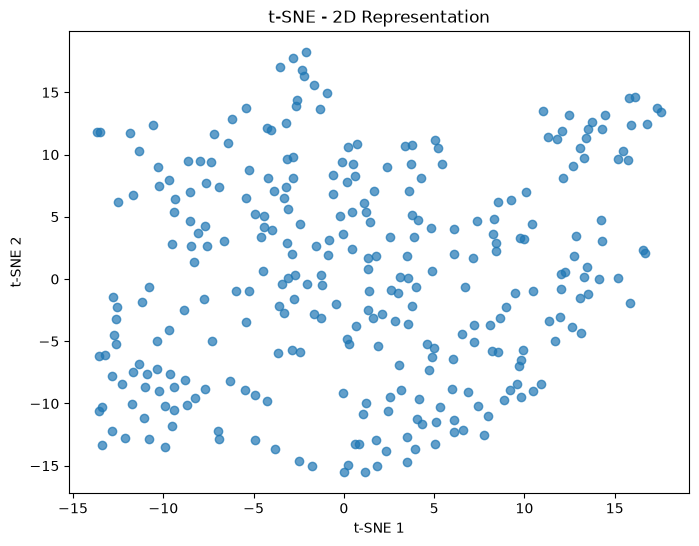

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tsne_df["tSNE1"],
    tsne_df["tSNE2"],
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE - 2D Representation")

plt.show()

# UMAP

UMAP is another nonlinear dimensionality reduction technique.

It is commonly used for high-dimensional visualization and low-dimensional representation.

In [33]:
import umap

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

In [ ]:
umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(
    X_scaled
)

umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)

umap_df.head()

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP - 2D Representation")

plt.show()

# Autoencoder

An Autoencoder is a Neural Network that learns a compressed representation of the input.

Flow:

Input → Encoder → Latent Representation → Decoder → Reconstruction

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense
)

In [ ]:
input_size = X_scaled.shape[1]

input_layer = Input(
    shape=(input_size,)
)

encoded = Dense(
    3,
    activation="relu",
    name="compressed_layer"
)(input_layer)

decoded = Dense(
    input_size,
    activation="linear"
)(encoded)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoded
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

In [ ]:
autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Autoencoder Training Complete")

In [ ]:
encoder = Model(
    inputs=input_layer,
    outputs=encoded
)

compressed_data = encoder.predict(
    X_scaled,
    verbose=0
)

compressed_df = pd.DataFrame(
    compressed_data,
    columns=[
        "Latent1",
        "Latent2",
        "Latent3"
    ]
)

compressed_df.head()

In [ ]:
print(
    "Original Dimensions:",
    X_scaled.shape
)

print(
    "Compressed Dimensions:",
    compressed_df.shape
)

In [ ]:
reconstructed_data = autoencoder.predict(
    X_scaled,
    verbose=0
)

reconstructed_df = pd.DataFrame(
    reconstructed_data,
    columns=X.columns
)

reconstructed_df.head()